<a href="https://colab.research.google.com/github/Prabhjot-Singh1/Concurrent-Programming-Lab/blob/main/CP_FINAL_PRACTICAL_EXAM/CP_Practical_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install numba -q

In [2]:
import numpy as np
from numba import cuda
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist  # MNIST is built into Keras/TensorFlow

# Load real MNIST data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"MNIST Loaded!")
print(f"Training images: {x_train.shape}")   # (60000, 28, 28)
print(f"Test images:     {x_test.shape}")    # (10000, 28, 28)
print(f"Pixel range: {x_train.min()} to {x_train.max()}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST Loaded!
Training images: (60000, 28, 28)
Test images:     (10000, 28, 28)
Pixel range: 0 to 255


In [3]:
# ── Constants ──────────────────────────────────────────────────
IMAGE_WIDTH  = 28
IMAGE_HEIGHT = 28
IMAGE_SIZE   = IMAGE_WIDTH * IMAGE_HEIGHT   # 784
NUM_IMAGES   = 100                          # use first 100 images
THRESHOLD    = 128
BLOCK_SIZE   = 256

# ── CUDA Kernel ────────────────────────────────────────────────
@cuda.jit
def grayscale_threshold(input_pixels, output_pixels, threshold):
    idx = cuda.grid(1)   # unique pixel index per thread
    if idx < input_pixels.size:
        if input_pixels[idx] >= threshold:
            output_pixels[idx] = 255   # white
        else:
            output_pixels[idx] = 0     # black

# ── Prepare real MNIST data ────────────────────────────────────
# Take first 100 images, flatten each 28x28 → 784
images = x_train[:NUM_IMAGES]                              # shape: (100, 28, 28)
h_input = images.reshape(-1).astype(np.uint8)             # shape: (78400,)

print(f"Using {NUM_IMAGES} real MNIST images")
print(f"Total pixels: {h_input.shape[0]}")

# ── Copy CPU → GPU ─────────────────────────────────────────────
d_input  = cuda.to_device(h_input)
d_output = cuda.device_array(h_input.size, dtype=np.uint8)

# ── Launch Kernel ──────────────────────────────────────────────
num_blocks = (h_input.size + BLOCK_SIZE - 1) // BLOCK_SIZE
print(f"Launching: {num_blocks} blocks × {BLOCK_SIZE} threads")

grayscale_threshold[num_blocks, BLOCK_SIZE](d_input, d_output, THRESHOLD)

# ── Copy GPU → CPU ─────────────────────────────────────────────
h_output = d_output.copy_to_host()

# ── Stats ──────────────────────────────────────────────────────
white = np.sum(h_output == 255)
black = np.sum(h_output == 0)
print(f"\nWhite pixels (>= {THRESHOLD}): {white}")
print(f"Black pixels (<  {THRESHOLD}): {black}")

Using 100 real MNIST images
Total pixels: 78400
Launching: 307 blocks × 256 threads

White pixels (>= 128): 10005
Black pixels (<  128): 68395


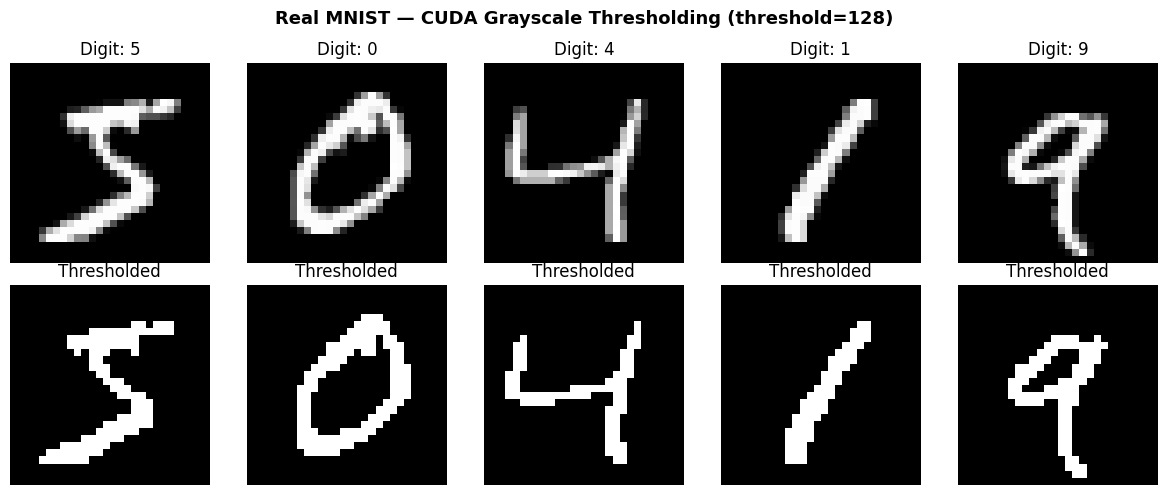

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i in range(5):
    # BEFORE
    before = h_input[i * IMAGE_SIZE : (i+1) * IMAGE_SIZE].reshape(28, 28)
    axes[0][i].imshow(before, cmap='gray', vmin=0, vmax=255)
    axes[0][i].set_title(f"Digit: {y_train[i]}", fontsize=12)
    axes[0][i].axis('off')

    # AFTER
    after = h_output[i * IMAGE_SIZE : (i+1) * IMAGE_SIZE].reshape(28, 28)
    axes[1][i].imshow(after, cmap='gray', vmin=0, vmax=255)
    axes[1][i].set_title(f"Thresholded", fontsize=12)
    axes[1][i].axis('off')

axes[0][0].set_ylabel("BEFORE", fontsize=12)
axes[1][0].set_ylabel("AFTER", fontsize=12)

plt.suptitle(f"Real MNIST — CUDA Grayscale Thresholding (threshold={THRESHOLD})",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

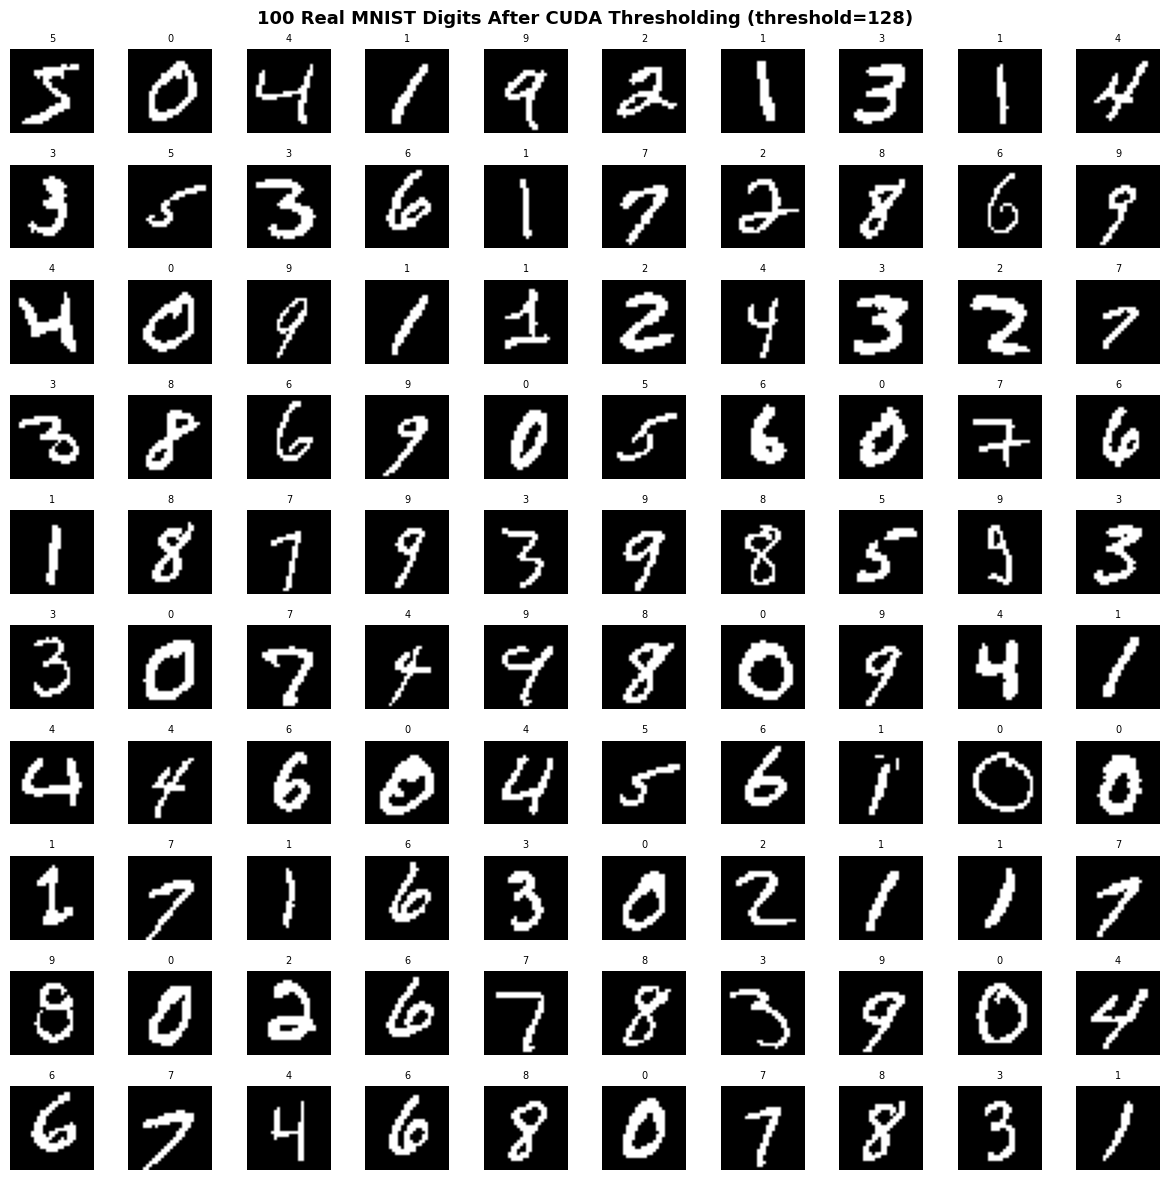

In [5]:
fig, axes = plt.subplots(10, 10, figsize=(12, 12))

for i in range(100):
    img = h_output[i * IMAGE_SIZE : (i+1) * IMAGE_SIZE].reshape(28, 28)
    ax  = axes[i // 10][i % 10]
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    ax.set_title(str(y_train[i]), fontsize=7)
    ax.axis('off')

plt.suptitle(f"100 Real MNIST Digits After CUDA Thresholding (threshold={THRESHOLD})",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()